## **Time Series Forecasting on Rossmann Sales Data using Chronos-2 Transformers**

In this notebook, we explore zero-shot time series forecasting on the Rossmann sales dataset using the Chronos-2 Transformer model. Chronos is a pretrained foundation model for time series forecasting that leverages Transformer architectures to generalize across different forecasting tasks without task-specific training. It is designed to address scenarios where building and fine-tuning dedicated forecasting models is costly or impractical.

The Rossmann dataset contains daily sales data for thousands of retail stores, along with relevant covariates such as promotions, holidays, and store-specific attributes, making it a realistic benchmark for real-world forecasting scenarios. In this notebook, we demonstrate the practical use of Chronos-2, compare univariate and covariate-based forecasting setups and perform feature engineering to analyze how the inclusion of additional features affects model performance and forecast quality.

### **Baseline**

In the univariate setup, the forecasting model conditions its predictions solely on the historical observations of the target variable (daily sales), without access to any exogenous information. In contrast, the covariate-based setup incorporates additional time-varying exogenous variables, such as promotions, store availability (open/closed), and holidays, including covariates that are known in advance over the forecasting horizon (known-future covariates), allowing the model to leverage future contextual information when generating predictions. In all experiments, the model is tasked with forecasting daily sales over a fixed horizon of 30 days, reflecting a realistic planning window for inventory management and promotion planning in retail settings.

In [9]:
import pandas as pd

covariates_table = pd.DataFrame([
    {
        "Covariate Name": "Customers",
        "Type": "Continuous",
        "Description": "Number of customers visiting the store on a given day",
        "Value Range / Encoding": "Non-negative integer (≥ 0)"
    },
    {
        "Covariate Name": "Open",
        "Type": "Binary",
        "Description": "Indicates whether the store is open on a given day",
        "Value Range / Encoding": "{0, 1}"
    },
    {
        "Covariate Name": "Promo",
        "Type": "Binary",
        "Description": "Indicates whether a promotion is active",
        "Value Range / Encoding": "{0, 1}"
    },
    {
        "Covariate Name": "StateHoliday",
        "Type": "Categorical",
        "Description": "Indicates the type of state/public holiday",
        "Value Range / Encoding": "{0, 1, 2, 3}"
    },
    {
        "Covariate Name": "SchoolHoliday",
        "Type": "Binary",
        "Description": "Indicates whether the day is a school holiday",
        "Value Range / Encoding": "{0, 1}"
    },
    {
        "Covariate Name": "DayOfWeek",
        "Type": "Categorical",
        "Description": "Day of the week",
        "Value Range / Encoding": "{1, …, 7}"
    }
])

covariates_table.style.hide(axis="index")

Covariate Name,Type,Description,Value Range / Encoding
Customers,Continuous,Number of customers visiting the store on a given day,Non-negative integer (≥ 0)
Open,Binary,Indicates whether the store is open on a given day,"{0, 1}"
Promo,Binary,Indicates whether a promotion is active,"{0, 1}"
StateHoliday,Categorical,Indicates the type of state/public holiday,"{0, 1, 2, 3}"
SchoolHoliday,Binary,Indicates whether the day is a school holiday,"{0, 1}"
DayOfWeek,Categorical,Day of the week,"{1, …, 7}"


Both setups are systematically evaluated across three different context lengths (128, 256, and 512) in order to analyze how the amount of historical context and the inclusion of exogenous information affect forecasting performance.

#### **Univariate vs Covariate**

The table below reports the aggregate forecasting performance of Chronos-2 across different context lengths for both univariate and covariate-based setups



In [85]:
path = "../reports/baseline/wql_by_context.csv"
df = pd.read_csv(path)

df_display = df.copy()
numeric_cols = ["mean_wql", "std_wql", "mean_mae", "mean_rmse", "mean_p10_under", "mean_p90_over"]
df_display[numeric_cols] = df_display[numeric_cols].round(4)

df_display.style.hide(axis="index")

context_length,mode,mean_wql,std_wql,mean_mae,mean_rmse,mean_p10_under,mean_p90_over,n_stores
128,covariate,0.075000,0.021200,703.238900,888.658100,0.150100,0.081100,933
128,univariate,0.105800,0.018200,858.157500,1110.233700,0.003100,0.035200,933
256,covariate,0.071600,0.020200,669.286700,856.273300,0.120300,0.067700,933
256,univariate,0.113600,0.021300,951.846900,1244.956600,0.004100,0.049900,933
512,covariate,0.066200,0.016500,621.880700,788.159900,0.116400,0.182800,933
512,univariate,0.078300,0.030300,731.061400,937.368800,0.076800,0.100700,933


In [86]:
best_cov = df[df["mode"] == "covariate"].sort_values("mean_wql").iloc[0]
best_cov

context_length           512
mode               covariate
mean_wql            0.066229
std_wql             0.016461
mean_mae          621.880681
mean_rmse         788.159867
mean_p10_under      0.116399
mean_p90_over       0.182815
n_stores                 933
Name: 4, dtype: object

The results show a clear and consistent performance advantage of the covariate-based setup over the univariate setup across all evaluated context lengths. Moreover, increasing the context length leads to systematic improvements in forecasting accuracy, with the best overall performance achieved by the covariate model with context length 512 (mean WQL = 0.0662). Based on these findings, the covariate configuration with context length 512 is selected as the best-performing baseline and used as the reference setup for subsequent feature engineering and downstream analyses.

Below we show a qualitative comparison of baseline forecasts for a single store (Store 142), contrasting the univariate and covariate-based configurations to illustrate how the inclusion of covariates affects the predicted trajectories over the forecasting horizon.

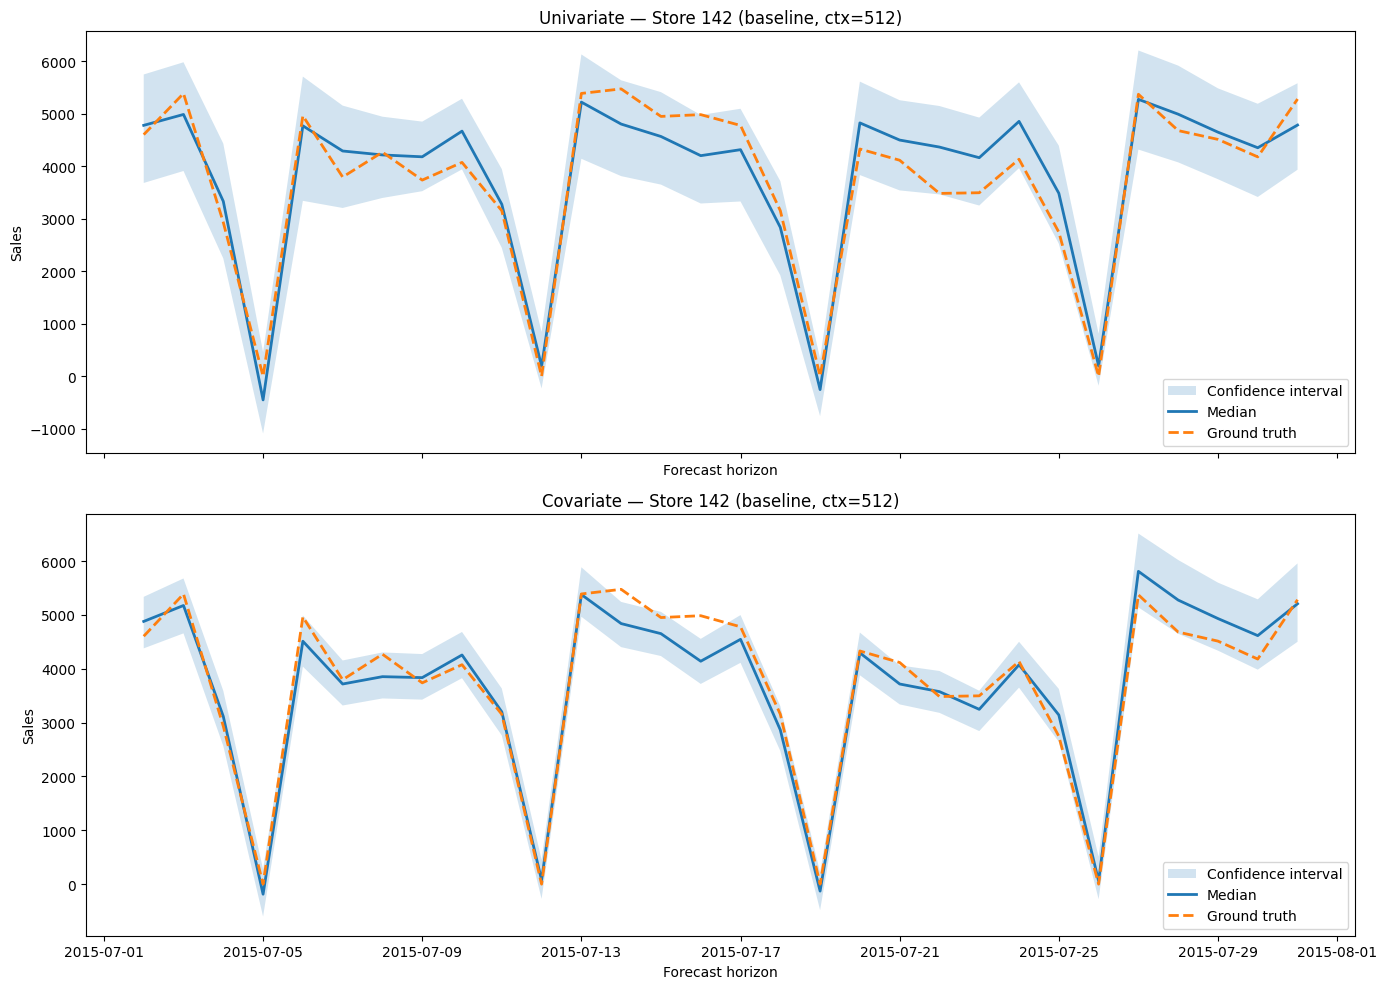

In [93]:
import matplotlib.pyplot as plt

store_id = 142
ctx = 512

uni_path = f"../outputs/baseline/forecasts/ctx_512/univariate/predictions/forecast_store_142.csv"
cov_path = f"../outputs/baseline/forecasts/ctx_512/covariate/predictions/forecast_store_142.csv"
gt_path  = f"../outputs/baseline/ground_truth/ground_truth_store_142.csv"

def load_pred(path: str) -> pd.DataFrame:
    df = pd.read_csv(path)
    df["timestamp"] = pd.to_datetime(df["timestamp"])
    df["p50"] = df["median"]
   
    return df[["timestamp", "p10", "p50", "p90"]].copy()

def load_gt(path: str) -> pd.DataFrame:
    df = pd.read_csv(path)
    df["timestamp"] = pd.to_datetime(df["timestamp"])
    ycol = "y_true" if "y_true" in df.columns else "target"
    return df[["timestamp", ycol]].rename(columns={ycol: "y_true"}).copy()

pred_uni = load_pred(uni_path)
pred_cov = load_pred(cov_path)
gt = load_gt(gt_path)

def plot_one(ax, pred: pd.DataFrame, gt: pd.DataFrame, title: str):
    df = pred.merge(gt, on="timestamp", how="left")

    ax.fill_between(df["timestamp"], df["p10"], df["p90"], alpha=0.2, label="Confidence interval")
    ax.plot(df["timestamp"], df["p50"], linewidth=2, label="Median")
    ax.plot(df["timestamp"], df["y_true"], linestyle="--", linewidth=2, label="Ground truth")

    ax.set_title(title)
    ax.set_xlabel("Forecast horizon")
    ax.set_ylabel("Sales")
    ax.legend()

fig, axes = plt.subplots(2, 1, figsize=(14, 10), sharex=True)

plot_one(axes[0], pred_uni, gt, f"Univariate — Store {store_id} (baseline, ctx={ctx})")
plot_one(axes[1], pred_cov, gt, f"Covariate — Store {store_id} (baseline, ctx={ctx})")

plt.tight_layout()
plt.show()



#### **Robustness test**

To assess the robustness of the selected forecasting configuration, we perform a series of stress tests that simulate realistic data perturbations and deployment-time uncertainties. These tests include:

 -  different levels of noise to the input series
 - shuffling temporal segments, masking parts of the input history
 - introducing time shifts and trend breaks, scaling distortions
 - dropping subsets of covariates
 - removing known-future information 
 
The goal of these experiments is to evaluate the stability of the model under distribution shifts and imperfect data conditions that commonly arise in real-world forecasting scenarios.

In [94]:
path = "../reports/baseline/robustness_summary.csv"
df_robust = pd.read_csv(path)

cols_to_show = [
    "test_name",
    "MAE_mean", "MAE_std", "MAE_median",
    "RMSE_mean", "RMSE_std", "RMSE_median",
    "PercentDifference_mean", "PercentDifference_std", "PercentDifference_median"
]

df_display = df_robust[cols_to_show].copy()

num_cols = [c for c in df_display.columns if c != "test_name"]
df_display[num_cols] = df_display[num_cols].round(3)

df_display.style.hide(axis="index")

test_name,MAE_mean,MAE_std,MAE_median,RMSE_mean,RMSE_std,RMSE_median,PercentDifference_mean,PercentDifference_std,PercentDifference_median
FeatureDrop,590.625000,250.169000,562.799000,659.830000,279.801000,629.319000,-18.126000,230.201000,-9.454000
MissingFuture,100.396000,127.599000,79.527000,124.386000,160.856000,97.376000,9.989000,42.110000,3.336000
Noise,82.108000,67.263000,70.050000,100.152000,92.993000,86.242000,1.254000,27.330000,-0.070000
PartialMask,332.068000,158.346000,310.975000,390.723000,190.087000,364.060000,-9.151000,106.487000,-2.204000
Scaling,62.238000,60.151000,54.404000,77.399000,85.531000,67.876000,-0.877000,21.146000,-0.338000
Shuffle,609.559000,254.030000,583.105000,680.305000,283.043000,652.161000,-11.841000,252.074000,-7.257000
StrongNoise,579.289000,245.060000,551.395000,660.223000,277.310000,631.757000,-20.380000,226.157000,-9.886000
TimeShift,354.045000,153.986000,332.779000,417.008000,181.744000,395.495000,-21.779000,120.385000,-9.978000
TrendBreak,1286.995000,662.576000,1173.448000,1767.158000,935.391000,1596.102000,153.628000,732.186000,67.110000


The figure bellow summarizes qualitative robustness comparisons for a representative store (Store 142), contrasting the baseline covariate forecast against several perturbation scenarios

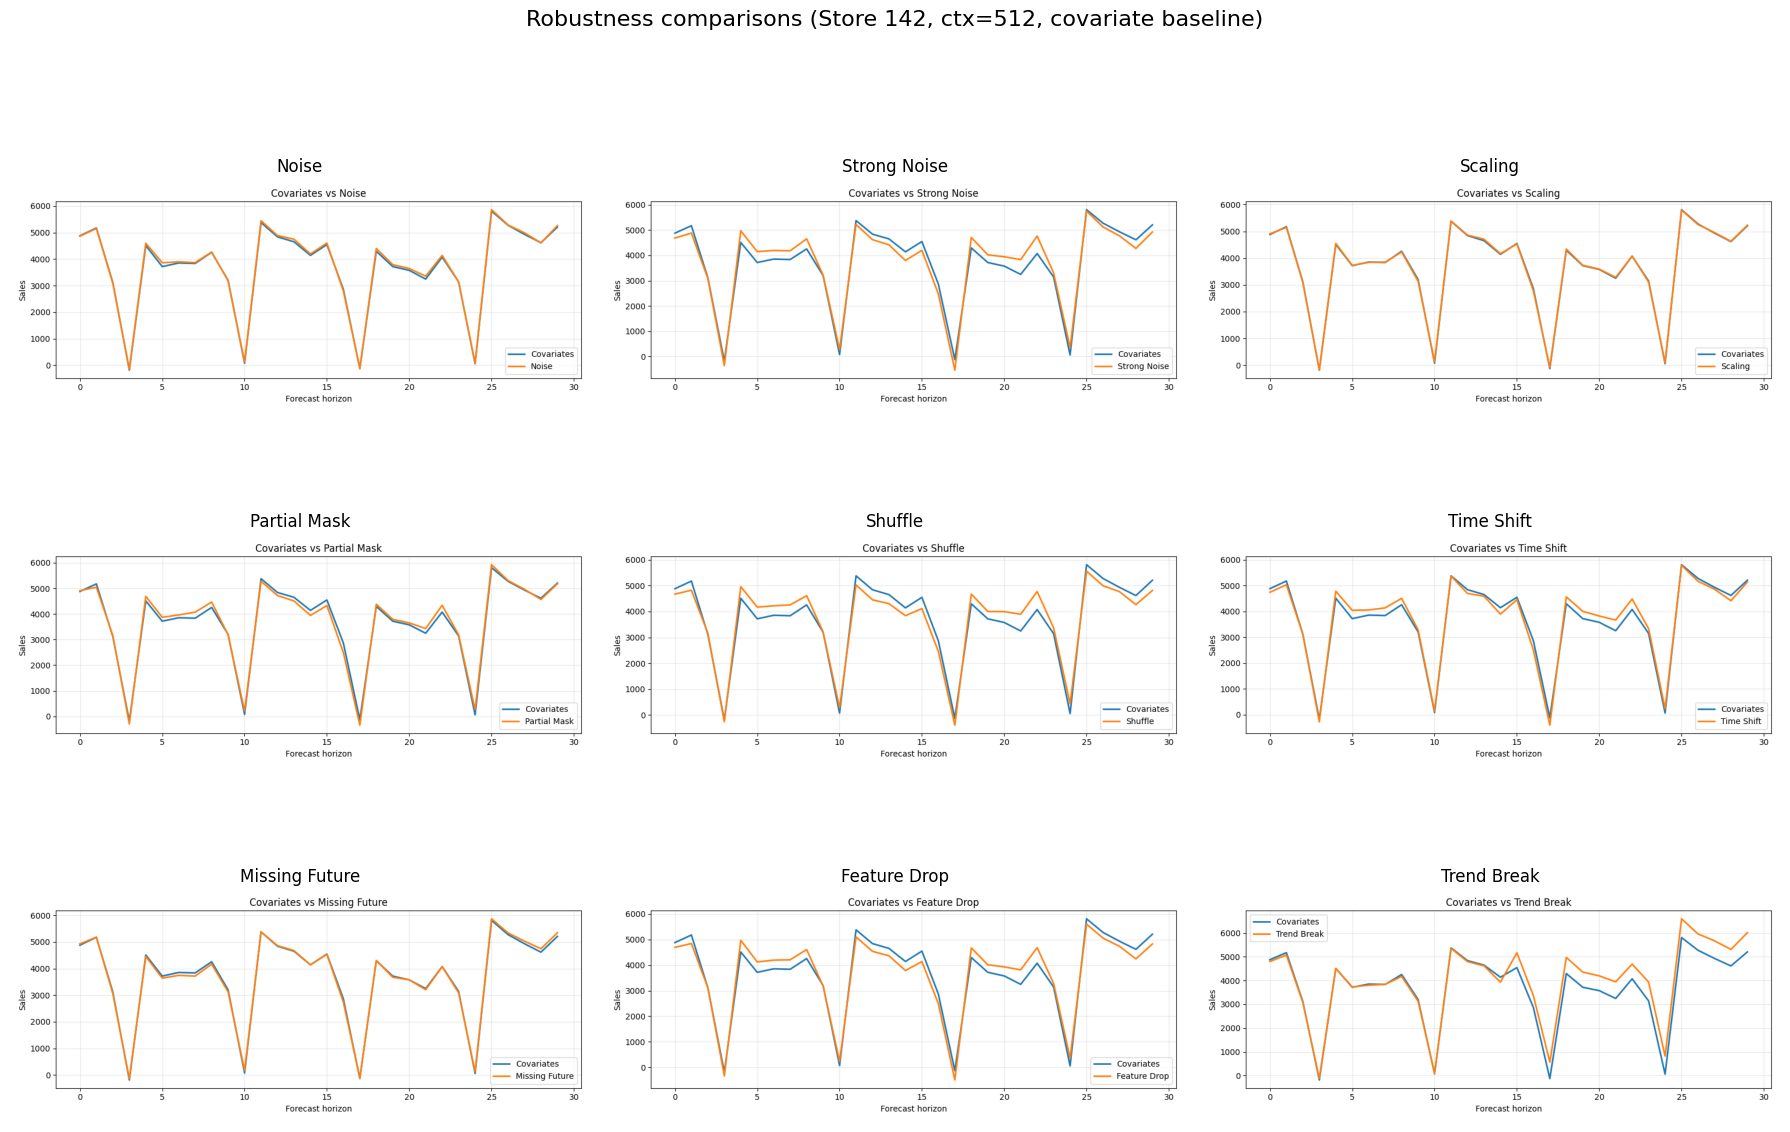

In [ ]:
from PIL import Image
import os

base_dir = "../visualization/baseline/ctx_512/robustness/comparison/good"

img_files = [
    "ctx_512_cov_vs_noise_store_142.png",
    "ctx_512_cov_vs_strong_noise_store_142.png",
    "ctx_512_cov_vs_scaling_store_142.png",
    "ctx_512_cov_vs_partial_mask_store_142.png",
    "ctx_512_cov_vs_shuffle_store_142.png",
    "ctx_512_cov_vs_time_shift_store_142.png",
    "ctx_512_cov_vs_missing_store_142.png",
    "ctx_512_cov_vs_feature_drop_store_142.png",
    "ctx_512_cov_vs_trend_break_store_142.png",
]

titles = [
    "Noise", "Strong Noise", "Scaling",
    "Partial Mask", "Shuffle", "Time Shift",
    "Missing Future", "Feature Drop", "Trend Break"
]

fig, axes = plt.subplots(3, 3, figsize=(18, 12))
axes = axes.flatten()

for ax, fname, title in zip(axes, img_files, titles):
    path = os.path.join(base_dir, fname)
    img = Image.open(path)
    ax.imshow(img)
    ax.set_title(title, fontsize=12)
    ax.axis("off")

plt.suptitle("Robustness comparisons (Store 142, ctx=512, covariate baseline)", fontsize=16, y=1.02)
plt.tight_layout()
plt.show()


Mild uncertainty (noise, scaling, partial masking) cause only small deviations from the baseline covariate forecast, suggesting reasonable stability under moderate corruption. Larger variations appear under structural shifts (shuffle, time shift, trend break) and when future covariate information is missing or dropped, indicating higher sensitivity to temporal misalignment and loss of contextual signals.

### **Extension 1: Feature engineering**

Based on the results of the baseline evaluation, where the covariate-based setup consistently outperformed the univariate configuration, we further investigate whether additional engineered features can improve forecasting performance. The goal of this extension is to enrich the model input with inductive biases that capture seasonality, calendar structure, and short- and long-term temporal dependencies, thereby enabling more accurate projections of future sales.

- **Seasonality (cyclical encoding).**  
Weekly and monthly seasonality are encoded using sine/cosine transformations to preserve cyclicity and avoid artificial discontinuities:

$$
\text{week\_sin} = \sin\left(2\pi \cdot \frac{\text{week}}{53}\right), \quad
\text{week\_cos} = \cos\left(2\pi \cdot \frac{\text{week}}{53}\right)
$$

$$
\text{month\_sin} = \sin\left(2\pi \cdot \frac{\text{month}}{12}\right), \quad
\text{month\_cos} = \cos\left(2\pi \cdot \frac{\text{month}}{12}\right)
$$

These features allow the model to capture smooth periodic patterns across weeks and months.

- **Calendar structure.**  
Discrete indicators provide coarse-grained temporal context:

$$
\text{quarter} \in \{1,2,3,4\}, \quad
\text{is\_month\_start} \in \{0,1\}, \quad
\text{is\_month\_end} \in \{0,1\}
$$

They encode quarterly effects and boundary effects at the beginning/end of each month.

- **Lagged target features.**  
To model short- and long-term dependencies, we include lagged target values:

$$
\text{lag}_k(t) = y(t-k), \quad k \in \{1,2,4,8,12,16,24,52\}
$$

These lags capture autocorrelation at multiple time scales (short-term dynamics up to yearly effects).

- **Lag availability masks.**  
For each lag feature, we include a binary availability mask:

$$
\text{lag\_}k\_\text{known}(t)=
\begin{cases}
1, & \text{if } y(t-k) \text{ is available} \\
0, & \text{otherwise}
\end{cases}
$$

This helps distinguish missing historical information (e.g., early timestamps) from true zero values.

- **Exponential moving averages.**  
We also include smoothed summaries of recent history (computed from past values only):

$$
\text{ema}_s(t) = \text{EMA}_s\big(y(t-1), y(t-2), \dots \big), \quad s \in \{4,8\}
$$


The table below reports the aggregate forecasting performance of the model after feature engineering for the selected best context length (CTX = 512), averaged across all evaluated stores.

In [ ]:
path = "../reports/extension1/wql_by_context.csv"
df = pd.read_csv(path)
df


,context_length,mode,mean_wql,std_wql,mean_mae,mean_rmse,mean_p10_under,mean_p90_over,n_stores
0,512,covariate,0.040996,0.016664,388.858088,496.369733,0.060885,0.153676,934


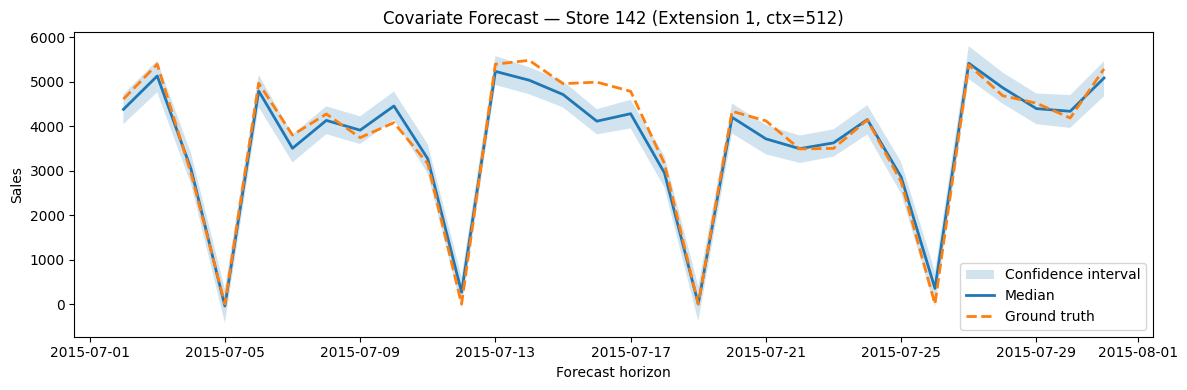

In [ ]:
fc_path = "../outputs/extension1/forecasts/ctx_512/covariate/forecast_store_142.csv"
gt_path = "../outputs/extension1/ground_truth/ground_truth_store_142.csv"

pred = pd.read_csv(fc_path)
gt = pd.read_csv(gt_path)

pred["timestamp"] = pd.to_datetime(pred["timestamp"])
gt["timestamp"] = pd.to_datetime(gt["timestamp"])

if {"0.1", "0.5", "0.9"}.issubset(pred.columns):
    pred = pred.rename(columns={"0.1": "p10", "0.5": "p50", "0.9": "p90"})
elif {"q0.1", "q0.5", "q0.9"}.issubset(pred.columns):
    pred = pred.rename(columns={"q0.1": "p10", "q0.5": "p50", "q0.9": "p90"})

ycol = "y_true" if "y_true" in gt.columns else "target"

df = pred[["timestamp", "p10", "median", "p90"]].merge(
    gt[["timestamp", ycol]], on="timestamp", how="left"
)

plt.figure(figsize=(12, 4))
plt.fill_between(df["timestamp"], df["p10"], df["p90"], alpha=0.2, label="Confidence interval")
plt.plot(df["timestamp"], df["median"], linewidth=2, label="Median")
plt.plot(df["timestamp"], df[ycol], linestyle="--", linewidth=2, label="Ground truth")

plt.title("Covariate Forecast — Store 142 (Extension 1, ctx=512)")
plt.xlabel("Forecast horizon")
plt.ylabel("Sales")
plt.legend()
plt.tight_layout()
plt.show()



Although the covariate baseline already captures the main demand drops, feature engineering improves the stability and calibration of the forecasts by explicitly encoding short- and long-term temporal dependencies and seasonal structure, leading to more accurate local dynamics and better uncertainty estimation.

### **Clustering shop analysis**

While the baseline and feature-engineered forecasting experiments provide insights into the average performance of Chronos across all stores, such global evaluations obscure important heterogeneity in retail demand patterns. In practice, different stores operate under distinct demand regimes, characterized by varying levels of volatility, seasonality, promotion sensitivity and operational stability.

The objective of this extension is therefore twofold:

1. To identify distinct types of stores based on their historical sales behavior using an unsupervised clustering approach.
2. To analyze how the impact of additional engineered features varies across these demand regimes, rather than assuming a uniform effect across all stores.

To enable clustering, a shop-level dataset is constructed, where each store is represented by a fixed-length feature vector obtained by aggregating its historical time series.

The clustering is performed using the *K-Means* algorithm on standardized shop-level features. The number of clusters *k* is selected via *Silhouette analysis*, by evaluating clustering quality over a predefined range of candidate values and selecting the configuration that maximizes the Silhouette score. This ensures a suitable trade-off between cluster compactness and separation, resulting in interpretable and behaviorally distinct store groups.


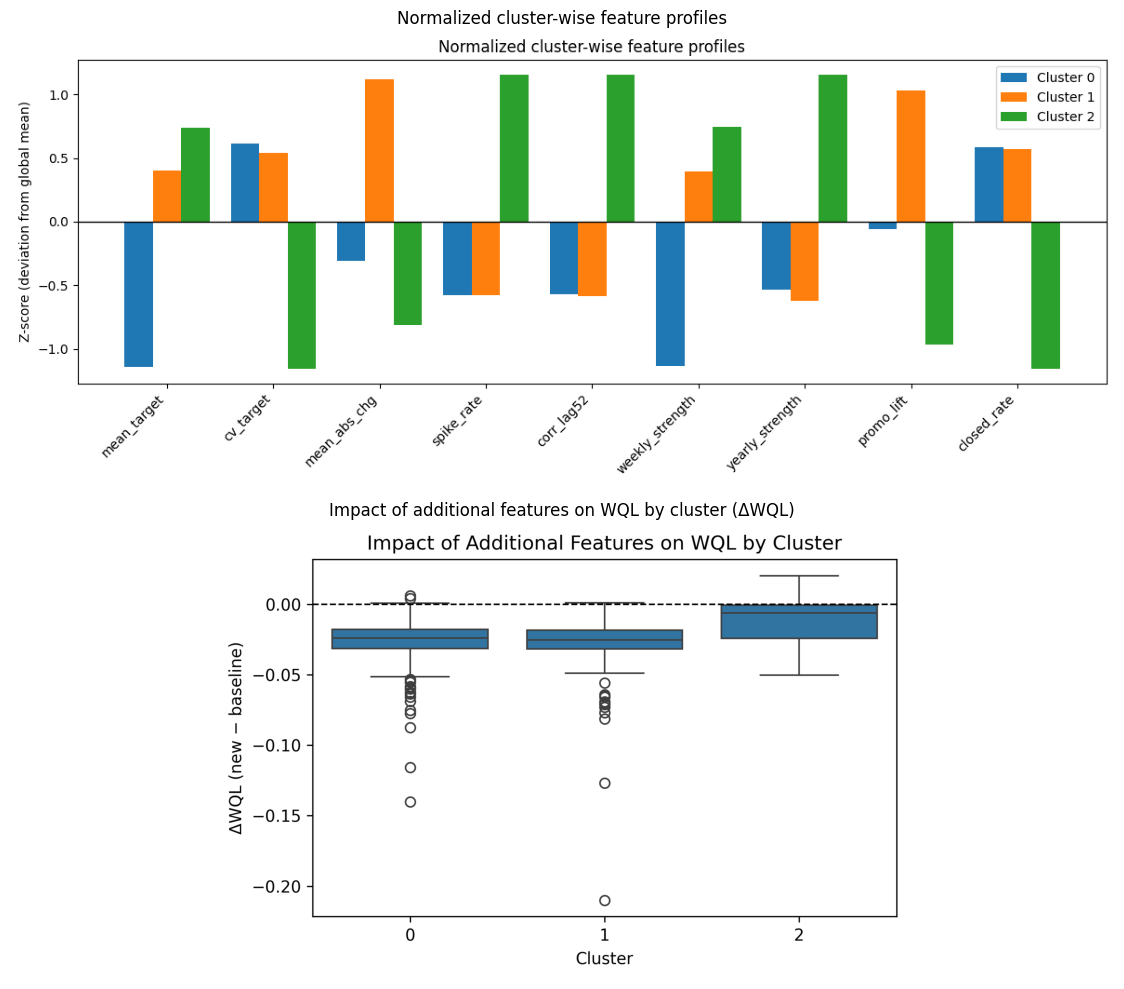

In [ ]:
base_fig_dir = "../outputs/figures"

img_profiles = Image.open(f"{base_fig_dir}/cluster_profiles_kmeans.png")
img_delta = Image.open(f"{base_fig_dir}/delta_wql_by_cluster.png")

fig, axes = plt.subplots(2, 1, figsize=(12, 10))

axes[0].imshow(img_profiles)
axes[0].axis("off")
axes[0].set_title("Normalized cluster-wise feature profiles")

axes[1].imshow(img_delta)
axes[1].axis("off")
axes[1].set_title("Impact of additional features on WQL by cluster (ΔWQL)")

plt.tight_layout()
plt.show()

The selected clustering configuration results in three distinct clusters, each corresponding to a characteristic retail demand regime. Based on aggregated feature profiles, the clusters can be interpreted as follows:

**Cluster 0 — Small & Unstable Promotion-Driven Stores**  
Stores with lower average sales, high variability, strong promotion effects, and a higher fraction of closed days.  
Demand patterns are dominated by short-term fluctuations and external shocks.

**Cluster 1 — Large Promotion-Driven Stores**  
High-volume stores exhibiting strong promotion sensitivity and elevated volatility. Despite higher sales levels, demand remains less predictable due to promotion-induced spikes and weak long-term temporal dependence.

**Cluster 2 — Stable Seasonal Stores**  
Large and operationally stable stores characterized by strong seasonal structure, positive long-term autocorrelation, low volatility, and limited promotion sensitivity. This cluster represents the most regular and predictable demand regime.

#### *Conclusion*

The impact of feature engineering on probabilistic forecasting performance differs substantially across the identified demand regimes.

For this *Cluster 0*, the introduction of additional features leads to a substantial and consistent improvement in probabilistic accuracy. The negative mean and median values of ΔWQL indicate that most stores benefit from the enhanced feature set. This suggests that for small and unstable stores, where demand is driven by short-term shocks and irregular patterns, the inclusion of seasonal and correlation-based information provides valuable structure that Chronos cannot reliably infer from the target history alone.

The *Cluster* 1 exhibits the largest average improvement among all demand regimes, indicating that large, promotion-driven stores benefit the most from the inclusion of additional features. At the same time, the high variability in ΔWQL reflects the heterogeneous nature of this group: while some stores strongly align with the engineered temporal and seasonal patterns, others remain dominated by irregular promotional shocks. Consequently, feature engineering acts as a powerful enabler for a subset of these stores, resulting in both large gains and substantial dispersion in performance improvements.

In contrast to the other regimes, *Cluster 2* shows a much smaller and less consistent response to feature engineering. The improvements in ΔWQL are marginal on average, and for a non-trivial fraction of stores the additional features provide no benefit or even introduce mild degradation. This indicates that Chronos already captures the dominant structure of stable, strongly seasonal demand regimes using the target history alone. In such settings, additional covariates offer limited incremental information and may partially interfere with well-learned patterns.

These results demonstrate that the effectiveness of feature engineering is **regime-dependent**. Additional engineered features are most beneficial for volatile and promotion-driven demand patterns, where the target history alone is insufficient to capture complex short-term dynamics. In contrast, for stable and highly seasonal stores, Chronos already provides strong performance without additional covariates, limiting the marginal utility of further feature augmentation.
